In [72]:
# Imports used throughout the code
import numpy as np
from math import floor
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torchsummary import summary
import copy
from torch import nn, tensor, float32
from sklearn.model_selection import train_test_split

# Load the 3 .npy files
file_path1 = 'pub_out.npy'
public_output = np.load(file_path1)
file_path2 = 'pub_input.npy'
public_input = np.load(file_path2)
device = "cpu"

Loading data for CN

In [73]:
# Example data (replace with your actual data)
public_output = np.sqrt(public_output)


# Convert labels to a NumPy array if they are not already
public_input = np.array(public_input, dtype=np.float32)
public_output = np.array(public_output, dtype=np.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [74]:
# Define train and test dataset
x_train, x_test, y_train, y_test = train_test_split(
    public_input,public_output, test_size=0.2, random_state=42
)


In [75]:
# Define train and test dataset
def df_to_tensors(x_test, y_test):
    train_data = tensor(x_test, dtype=float32).unsqueeze(1).to(device)
    labels = tensor(y_test, dtype=float32).unsqueeze(1).to(device)

    return train_data, labels

# Define a DataSet type based on the previous one to hold the tensors of input needed to train the nn
class PandasData(Dataset):
    def __init__(self, x_train, y_train):
        self.input = tensor(x_train, dtype=float32).unsqueeze(1).to(device)
        self.labels = tensor(y_train, dtype=float32).unsqueeze(1).to(device)

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

In [76]:
# Initialise the dataset with the training and testing data
test_input, test_labels = df_to_tensors(x_test, y_test)

data_dict = {
    "train": PandasData(x_train, y_train),
    "x_test": test_input,
    "y_test": test_labels,
}

In [78]:
# Apply reflection over x-axis
class ApplyReflectionXSymmetry(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Apply reflection over x-axis
        x_reflect_x = x.flip(2)
        return x_reflect_x

# Apply reflection over y-axis
class ApplyReflectionYSymmetry(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Apply reflection over y-axis
        x_reflect_y = x.flip(3)
        return x_reflect_y

# Apply reflection over main diagonal
class ApplyReflectionMainDiagonal(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Apply reflection over the main diagonal (transpose the last two dimensions)
        # and then flip along the horizontal axis to match the diagonal reflection
        x_reflect_main_diag = x.transpose(2, 3)
        return x_reflect_main_diag

# Apply reflection over anti diagonal
class ApplyReflectionAntiDiagonal(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Apply reflection over the anti-diagonal
        # First, flip the matrix along both the horizontal and vertical axes
        # Then transpose the last two dimensions to match the anti-diagonal reflection
        x_reflect_anti_diag = x.flip(2).flip(3).transpose(2, 3)
        return x_reflect_anti_diag

# Apply Rotation of 90
class ApplyRotation90Symmetry(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Rotate tensor by 90 degrees
        x_rot_90 = torch.rot90(x, k=1, dims=(2, 3))
        return x_rot_90

# Apply Rotation of 180
class ApplyRotation180Symmetry(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Rotate tensor by 180 degrees
        x_rot_180 = torch.rot90(x, k=2, dims=(2, 3))
        return x_rot_180

# Apply Rotation of 270
class ApplyRotation270Symmetry(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Rotate tensor by 270 degrees
        x_rot_270 = torch.rot90(x, k=3, dims=(2, 3))
        return x_rot_270


Techy symmetry

Architecture

In [79]:
# Symmetry combining class
class SymmetricModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.augmentations = nn.ModuleList([
            ApplyReflectionXSymmetry(),
            ApplyReflectionYSymmetry(),
            ApplyReflectionMainDiagonal(),
            ApplyReflectionAntiDiagonal(),
            ApplyRotation90Symmetry(),
            ApplyRotation180Symmetry(),
            ApplyRotation270Symmetry(),
        ])

    def forward(self, x):
        outputs = [self.model(aug(x)) for aug in self.augmentations]
        outputs.append(self.model(x))  # Include the original input
        outputs = torch.stack(outputs, dim=0)
        return outputs.mean(dim=0)

# Forward pass for symmetrical input variants
def create_symmetric_model():
    return nn.Sequential(

        # Layer1
        nn.Conv2d(1, 16, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),
        #nn.Dropout(p=0.1),  # Add dropout layer
        nn.AvgPool2d(kernel_size=(2, 2)),

        # Layer2
        nn.Conv2d(16, 32, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),
        # nn.Dropout(p=0.5),  # Add dropout layer
        nn.AvgPool2d(kernel_size=(2, 2)),

        # Layer3
        nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),
        # nn.Dropout(p=0.5),  # Add dropout layer
        nn.AvgPool2d(kernel_size=(2, 2)),

        # Layer4 (no avg)
        nn.Conv2d(64, 64, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),

        # Layer5 (no avg)
        nn.Conv2d(64, 64, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),

        # Layer6
        nn.Conv2d(64, 32, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),
        # nn.Dropout(p=0.5),  # Add dropout layer
        nn.AvgPool2d(kernel_size=(2, 2)),

        # Layer7
        nn.Conv2d(32, 16, kernel_size=(3, 3), padding=(1, 1)),
        nn.ReLU(),
        # nn.Dropout(p=0.5),  # Add dropout layer

        # input flatten before final 2 layers
        nn.Flatten(start_dim=1),

        # Layer8 (no avg)
        nn.ReLU(),
        nn.Linear(16*2*2, 32, bias=False),

        # Layer9 (no avg)
        nn.ReLU(),
        nn.Linear(32, 1, bias=False),
    )


Loss Metric

In [80]:
# Root mean square percentage error function for training
def rmspe(y_pred, y_true):
    return ((y_true - y_pred) / y_true).pow(2).mean().sqrt()

In [81]:
import torch
from torch.utils.data import DataLoader
from math import floor
from tqdm import tqdm
import copy

def train_model2(
    data, model, nepochs=1, lr=1e-6, batch_size=1, print_every=1, prompt_every=200
):

    # First move all the data and the model to the GPU for processing
    model.to(device)
    x_test = data["x_test"].to(device)
    y_test = data["y_test"].to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_dict = {"train": [], "test": []}

    num_batches = floor(len(data["train"]) / batch_size)

    # Initiate best model for saving
    best_model = None
    best_test_loss = float('inf')

    # Begin the per epoch training loop
    for epoch in tqdm(range(nepochs)):
        epoch_loss_sum = 0

        # First train the model on the training batches
        for x_batch, y_batch in DataLoader(
            data["train"], batch_size=batch_size, shuffle=True
        ):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            # now calculate the test loss and adjust weights accordingly
            loss = rmspe(y_pred, y_batch)
            epoch_loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Add training to loss dict
        train_loss = epoch_loss_sum / num_batches
        loss_dict["train"].append(train_loss)

        # Calculate error for test batch
        with torch.no_grad():
            y_pred = model(x_test)
            test_loss = rmspe(y_pred, y_test)
            loss_dict["test"].append(test_loss.item())

            # Check if current model is better than best via test error
            if test_loss.item() < best_test_loss:
                best_test_loss = test_loss.item()
                best_model = copy.deepcopy(model)

            # Print out error info for this epoch
            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch + 1} - Train Loss: {train_loss}, Test Loss: {test_loss.item()}, Best Test Loss: {best_test_loss}")

            # Check if epoch is on stopping point
            if (epoch + 1) % prompt_every == 0:
                cont = input(f"Continue training after epoch {epoch + 1}? (y/n): ").strip().lower()
                if cont != 'y':
                    print("Stopping training.")
                    best_model.to('cpu')
                    model.to('cpu')
                    return best_model, model, loss_dict

    # Move model and data to CPU from GPU
    best_model.to('cpu')
    model.to('cpu')
    return model, best_model, loss_dict

def rmspe(y_pred, y_true):
    return torch.sqrt(torch.mean(((y_true - y_pred) / y_true) ** 2))

# Example usage:
# data = {"train": train_dataset, "x_test": x_test.to(device), "y_test": y_test.to(device)}
# best_model, latest_model, loss_dict = train_model2(data, model, nepochs=100, lr=1e-4, batch_size=32, print_every=1, prompt_every=10)


In [82]:
symmetric_model_initiator = SymmetricModelWrapper(create_symmetric_model())
# Print the summary of the model

# Move the model to the GPU
symmetric_model_initiator.to(device)

# Ensure all parameters are on the GPU
symmetric_model_initiator = symmetric_model_initiator.to(device)

# Print the summary of the model
summary(symmetric_model_initiator, (1, 40, 40), device=str(device))


# Initialise model and begin training
symmetric_model, best_symmetric_model, symmetric_loss = train_model2(
    data_dict,
    SymmetricModelWrapper(create_symmetric_model()),
    nepochs=50000,
    lr=0.0002,
    batch_size=16,
    print_every=20,
    prompt_every=1000
)

 10%|█         | 5220/50000 [1:44:43<13:31:27,  1.09s/it]

Epoch 5220 - Train Loss: 0.0034977233272988394, Test Loss: 0.004643335472792387, Best Test Loss: 0.004458656068891287


 10%|█         | 5240/50000 [1:45:05<13:28:15,  1.08s/it]

Epoch 5240 - Train Loss: 0.0037009079978487128, Test Loss: 0.0065025147050619125, Best Test Loss: 0.004458656068891287


 11%|█         | 5260/50000 [1:45:27<13:46:56,  1.11s/it]

...

Epoch 5980 - Train Loss: 0.0030914096446449765, Test Loss: 0.004945853725075722, Best Test Loss: 0.004458656068891287


 12%|█▏        | 5999/50000 [1:59:13<13:42:05,  1.12s/it]

Epoch 6000 - Train Loss: 0.002610333963768579, Test Loss: 0.004633267410099506, Best Test Loss: 0.004458656068891287


 12%|█▏        | 5999/50000 [1:59:19<14:35:11,  1.19s/it]

Stopping training.


Train Model

C:\Users\20222535\AppData\Local\Temp\ipykernel_32248\3380513932.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2)


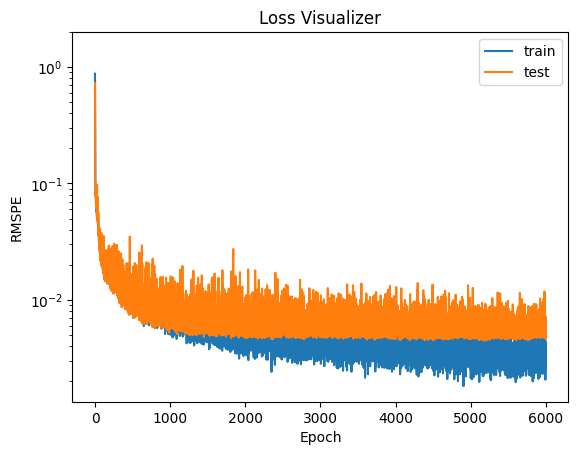

In [83]:
# Compare the train and test error
plt.semilogy(symmetric_loss["train"], label="train")
plt.semilogy(symmetric_loss["test"], label="test")
plt.title("Loss Visualizer")
plt.xlabel("Epoch")
plt.ylabel("RMSPE")
plt.ylim(0, 2)
plt.legend()
plt.show()

In [84]:
torch.save(best_symmetric_model, 'model.pth')

In [85]:
model = torch.load('model.pth')
model.eval()

SymmetricModelWrapper(
  (model): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU()
    (15): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
    (16): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (17): ReLU()
    (18): Flatten(start_dim=1, end_dim=-1)
    (19

In [86]:
# Save best model
torch.save(best_symmetric_model, 'model.pth')
model = torch.load('model.pth')

# Process private kaggle data for model
x_data_test = np.load('pri_in.npy')
x_data_test = x_data_test.reshape(-1, 1, 40, 40).astype(np.float32)  
x_data_test = torch.from_numpy(x_data_test).float()
model = torch.load('model.pth')

# Run model on data
with torch.no_grad():
    prediction = model(x_data_test).flatten().numpy()

# Make id list
ids = range(0, len(prediction))

# Add to a df
df_predictions = pd.DataFrame({
    "ID": ids,
    "Solution": prediction
})

# Export df as csv
df_predictions.to_csv('predictions2valid.csv', index=False)

torch.Size([500, 1, 40, 40])
